<a id="top"></a>
# Deteksi Fraud E-commerce Menggunakan LightGBM, Autoencoder, dan Feature Engineering Berbasis Entitas

Notebook ini adalah laporan eksperimen untuk bimbingan tugas akhir. Tujuannya adalah merangkum metodologi, alur eksperimen, eksplorasi dataset, artifact hasil, visualisasi utama, dan bahan diskusi pembimbing tanpa perlu membaca seluruh folder `/src`.

**Catatan penggunaan:** notebook ini hanya membaca raw data terpilih dan artifact dari `outputs/`. Tidak ada retraining model, tidak ada Optuna ulang, dan tidak ada training Autoencoder ulang.


## Daftar Isi

1. [Ringkasan Temuan Utama](#ringkasan-temuan)
2. [Project Overview](#project-overview)
3. [Dataset & Labeling Context](#dataset-labeling)
4. [Dataset Snapshot & Exploratory Overview](#dataset-snapshot)
5. [Experiment Flow](#experiment-flow)
6. [Artifact Map](#artifact-map)
7. [Temporal Split](#temporal-split)
8. [Temporal EDA](#temporal-eda)
9. [Experiment Scenarios](#experiment-scenarios)
10. [Final Model Comparison](#final-model-comparison)
11. [Operational Threshold & Business-Impact Simulation](#business-impact)
12. [Autoencoder Findings](#autoencoder-findings)
13. [Diagnostic Notes](#diagnostic-notes)
14. [Feature Engineering Findings](#feature-engineering-findings)
15. [Ablation & Negative Experiments](#ablation-negative)
16. [Final Model](#final-model)
17. [Discussion](#discussion)
18. [Limitations & Future Work](#limitations-future-work)
19. [Checklist Diskusi Bimbingan](#advisor-checklist)
20. [Catatan Eksekusi Notebook](#execution-notes)


<a id="setup"></a>
## Setup Notebook

Cell setup berikut hanya menyiapkan path, konfigurasi tampilan, dan helper ringan. Tidak ada proses training atau tuning.


In [24]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "outputs").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data" / "raw"

pd.set_option("display.max_columns", 90)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

MISSING_NOTES = []


In [25]:
ARTIFACTS = {
    "train_transaction": "data/raw/train_transaction.csv",
    "train_identity": "data/raw/train_identity.csv",
    "split_summary": "outputs/split_summary.json",
    "final_summary": "outputs/final_report/final_summary.json",
    "final_model_comparison": "outputs/final_report/final_model_comparison.csv",
    "diagnostic_notes": "outputs/final_report/diagnostic_notes.md",
    "final_defense_notes": "outputs/final_diagnostics/final_defense_notes.md",
    "feature_importance": "outputs/optuna/baseline_lgbm_entity_time_amount_features/feature_importance.csv",
    "feature_set_summary": "outputs/baseline_lgbm_entity_time_amount_features/feature_set_summary.json",
    "next_controlled": "outputs/final_comparison/next_controlled_experiments.csv",
    "fe_ae_fine_ensemble": "outputs/final_comparison/fe_ae_fine_ensemble_comparison.csv",
    "latent_ablation": "outputs/final_comparison/latent_dim_ablation.csv",
    "ae_augmented": "outputs/final_comparison/ae_augmented_comparison.csv",
    "three_model_ensemble": "outputs/final_comparison/three_model_ensemble_comparison.csv",
    "scores_test": "outputs/fe_ae_controlled_experiments/A_score_ensemble_fe_tuned_ae_tuned/scores_test.csv",
    "bootstrap_ci": "outputs/final_diagnostics/bootstrap_pr_auc_ci.csv",
    "bootstrap_delta_summary": "outputs/final_diagnostics/bootstrap_delta_summary.json",
    "temporal_degradation": "outputs/final_diagnostics/temporal_degradation_by_bin.csv",
    "score_correlation": "outputs/final_diagnostics/score_correlation_summary.json",
    "reconstruction_summary": "outputs/final_diagnostics/reconstruction_error_class_summary.csv",
    "inference_complexity": "outputs/final_diagnostics/inference_complexity_summary.csv",
    "operational_fpr": "outputs/final_diagnostics/business_impact/operational_fpr_simulation.csv",
    "operational_delta": "outputs/final_diagnostics/business_impact/operational_fpr_delta_summary.csv",
    "business_notes": "outputs/final_diagnostics/business_impact/business_impact_notes.md",
}


In [26]:
RAW_TRANSACTION_COLS = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain", "dist1",
]
RAW_IDENTITY_COLS = ["TransactionID", "DeviceType", "DeviceInfo", "id_30", "id_31", "id_33"]

HIGHLIGHT_FEATURES = [
    "amt_mean_by_card1_addr1",
    "amt_std_by_card1_addr1",
    "count_card1_addr1_P_emaildomain",
    "count_card1_P_emaildomain",
    "amt_mean_by_card1_P_emaildomain",
]


In [27]:
def resolve_path(path):
    artifact_path = Path(path)
    if artifact_path.is_absolute():
        return artifact_path
    return PROJECT_ROOT / artifact_path


def register_note(message):
    MISSING_NOTES.append(message)
    print(message)


def safe_read_csv(path, context=None, **kwargs):
    artifact_path = resolve_path(path)
    label = context or str(path)
    if not artifact_path.exists():
        register_note(f"Catatan: artifact untuk {label} tidak ditemukan: {artifact_path}")
        return None
    try:
        return pd.read_csv(artifact_path, **kwargs)
    except Exception as exc:
        register_note(f"Catatan: artifact untuk {label} gagal dibaca: {exc}")
        return None


def safe_read_json(path, context=None):
    artifact_path = resolve_path(path)
    label = context or str(path)
    if not artifact_path.exists():
        register_note(f"Catatan: artifact untuk {label} tidak ditemukan: {artifact_path}")
        return None
    try:
        with artifact_path.open("r", encoding="utf-8") as file:
            return json.load(file)
    except Exception as exc:
        register_note(f"Catatan: artifact untuk {label} gagal dibaca: {exc}")
        return None


In [28]:
def safe_read_text(path, context=None):
    artifact_path = resolve_path(path)
    label = context or str(path)
    if not artifact_path.exists():
        register_note(f"Catatan: artifact untuk {label} tidak ditemukan: {artifact_path}")
        return None
    try:
        return artifact_path.read_text(encoding="utf-8")
    except Exception as exc:
        register_note(f"Catatan: artifact untuk {label} gagal dibaca: {exc}")
        return None


def note_table(message):
    return pd.DataFrame({"Catatan": [message]})


def numeric_round_table(df, digits=6):
    table = df.copy()
    numeric_columns = table.select_dtypes(include=["number"]).columns
    table[numeric_columns] = table[numeric_columns].round(digits)
    return table


In [29]:
def prepare_comparison(df):
    if df is None or df.empty:
        return pd.DataFrame()
    data = df.copy()
    if "model_name" not in data.columns and "model_id" in data.columns:
        data["model_name"] = data["model_id"]
    if "model_name" not in data.columns:
        data["model_name"] = data.index.astype(str)

    metric_cols = [c for c in data.columns if c.startswith(("validation_", "test_"))]
    metric_cols += ["selected_threshold", "total_features", "best_iteration"]
    for column in sorted(set(metric_cols)):
        if column in data.columns:
            data[column] = pd.to_numeric(data[column], errors="coerce")

    if "rank" not in data.columns and "test_pr_auc" in data.columns:
        data = data.sort_values("test_pr_auc", ascending=False).reset_index(drop=True)
        data.insert(0, "rank", np.arange(1, len(data) + 1))
    return data


In [30]:
def format_metric_table(df):
    data = prepare_comparison(df)
    if data.empty:
        return note_table("Data perbandingan model tidak tersedia.")
    desired = [
        "rank", "model_name", "validation_pr_auc", "test_pr_auc",
        "test_roc_auc", "test_precision", "test_recall", "test_f1",
        "test_mcc", "selected_threshold", "total_features", "is_standalone",
    ]
    available = [column for column in desired if column in data.columns]
    table = data[available].copy()
    table = table.rename(columns={
        "rank": "Rank", "model_name": "Model",
        "validation_pr_auc": "Validation PR-AUC", "test_pr_auc": "Test PR-AUC",
        "test_roc_auc": "Test ROC-AUC", "test_precision": "Precision",
        "test_recall": "Recall", "test_f1": "F1", "test_mcc": "MCC",
        "selected_threshold": "Threshold", "total_features": "Jumlah Fitur",
        "is_standalone": "Standalone",
    })
    return numeric_round_table(table)


In [31]:
def plot_bar(df, metric_col, label_col="model_name", title="", xlabel=None, top_n=12, color="#4c78a8"):
    data = prepare_comparison(df)
    if data.empty or metric_col not in data.columns or label_col not in data.columns:
        print(f"Catatan: data untuk plot {metric_col} tidak tersedia.")
        return
    plot_data = data[[label_col, metric_col]].copy()
    plot_data[metric_col] = pd.to_numeric(plot_data[metric_col], errors="coerce")
    plot_data = plot_data.dropna(subset=[metric_col]).sort_values(metric_col, ascending=False).head(top_n).iloc[::-1]
    if plot_data.empty:
        print(f"Catatan: data numerik untuk plot {metric_col} tidak tersedia.")
        return

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_data))))
    ax.barh(plot_data[label_col], plot_data[metric_col], color=color)
    ax.set_title(title or metric_col)
    ax.set_xlabel(xlabel or metric_col)
    ax.set_ylabel("")
    upper = min(1.0, max(float(plot_data[metric_col].max()) * 1.16, 0.05))
    ax.set_xlim(left=0, right=upper)
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + upper * 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


In [32]:
def plot_grouped_metric_bars(df, metric_cols, label_col="model_name", top_n=9, title="Perbandingan Metrik Test"):
    data = prepare_comparison(df)
    available = [column for column in metric_cols if column in data.columns]
    if data.empty or not available or label_col not in data.columns:
        print("Catatan: data untuk grouped bar chart tidak tersedia.")
        return
    sort_col = "test_pr_auc" if "test_pr_auc" in data.columns else available[0]
    plot_data = data[[label_col, sort_col] + available].copy()
    plot_data = plot_data.dropna(subset=available, how="all").sort_values(sort_col, ascending=False).head(top_n).iloc[::-1]

    labels = plot_data[label_col].tolist()
    y = np.arange(len(labels))
    bar_height = 0.8 / len(available)
    colors = ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]
    pretty = {"test_roc_auc": "ROC-AUC", "test_f1": "F1", "test_mcc": "MCC"}
    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(labels))))
    for index, metric in enumerate(available):
        offset = (index - (len(available) - 1) / 2) * bar_height
        ax.barh(y + offset, plot_data[metric].astype(float), height=bar_height, label=pretty.get(metric, metric), color=colors[index % len(colors)])
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Skor")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


In [33]:
def category_fraud_summary(df, column, top_n=10):
    if df is None or df.empty or column not in df.columns:
        return pd.DataFrame()
    temp = df[[column, "isFraud"]].copy()
    temp[column] = temp[column].astype("string").fillna("MISSING")
    grouped = temp.groupby(column, dropna=False)["isFraud"].agg(["count", "sum"]).reset_index()
    grouped = grouped.rename(columns={"sum": "fraud_count"})
    grouped["fraud_rate"] = grouped["fraud_count"] / grouped["count"]
    grouped = grouped.sort_values("count", ascending=False).head(top_n)
    return grouped.sort_values("fraud_rate", ascending=True)


def plot_category_fraud_rate(df, column, top_n=10):
    summary = category_fraud_summary(df, column, top_n=top_n)
    if summary.empty:
        print(f"Catatan: kolom {column} tidak tersedia untuk fraud-rate plot.")
        return
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(summary))))
    ax.barh(summary[column].astype(str), summary["fraud_rate"] * 100, color="#4c78a8")
    ax.set_title(f"Fraud Rate per {column} (top {top_n} by volume)")
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


In [34]:
def markdown_bullets_to_frame(text):
    if not text:
        return note_table("Catatan markdown tidak tersedia.")
    rows = []
    section = "Umum"
    for line in text.splitlines():
        if line.startswith("## "):
            section = line.replace("## ", "", 1).strip()
        elif line.startswith("- "):
            rows.append({"Area": section, "Temuan": line[2:].strip()})
    if not rows:
        return note_table("File markdown tersedia, tetapi tidak ada bullet ringkasan.")
    return pd.DataFrame(rows)


<a id="ringkasan-temuan"></a>
## 1. Ringkasan Temuan Utama

Ringkasan ini ditujukan sebagai pembuka diskusi bimbingan. Angka utama diambil dari artifact final report yang sudah dihasilkan sebelumnya.


In [35]:
final_summary = safe_read_json(ARTIFACTS["final_summary"], "final summary")

if final_summary:
    summary_rows = [
        {"Aspek": "Best overall model", "Nilai": final_summary["best_overall_model"]["model_name"]},
        {"Aspek": "Best overall Test PR-AUC", "Nilai": final_summary["best_overall_model"]["test_pr_auc"]},
        {"Aspek": "Best standalone model", "Nilai": final_summary["best_standalone_model"]["model_name"]},
        {"Aspek": "Best standalone Test PR-AUC", "Nilai": final_summary["best_standalone_model"]["test_pr_auc"]},
        {"Aspek": "Delta ensemble vs FE tuned", "Nilai": final_summary["contributions"]["ae_contribution"]["ensemble_vs_fe_tuned_test_pr_auc_delta"]},
        {"Aspek": "Delta FE tuned vs baseline tuned", "Nilai": final_summary["contributions"]["feature_engineering_contribution"]["fe_tuned_vs_baseline_tuned_test_pr_auc_delta"]},
        {"Aspek": "Evaluation split", "Nilai": final_summary["evaluation_split"]},
    ]
    executive_summary_table = pd.DataFrame(summary_rows)
else:
    executive_summary_table = note_table("Final summary tidak tersedia.")

executive_summary_table


,Aspek,Nilai
0,Best overall model,FE-LGBM tuned + AE-LGBM tuned score ensemble
1,Best overall Test PR-AUC,0.533935
2,Best standalone model,Feature-engineered LightGBM tuned
3,Best standalone Test PR-AUC,0.529857
4,Delta ensemble vs FE tuned,0.004079
5,Delta FE tuned vs baseline tuned,0.028419
6,Evaluation split,chronological test split


Inti hasil sementara:

- **Feature engineering** berbasis entitas, waktu, dan nominal transaksi adalah kontribusi standalone paling kuat.
- **Autoencoder** tidak menjadi model standalone terbaik, tetapi memberi sinyal probabilistik komplementer pada score ensemble.
- **Temporal split** membuat evaluasi lebih realistis dan lebih ketat dibanding random split.
- **PR-AUC** dipakai sebagai metrik utama karena fraud merupakan kelas minoritas.


<a id="project-overview"></a>
## 2. Project Overview

Dataset yang digunakan adalah **IEEE-CIS Fraud Detection** dari Kaggle. Dataset ini berisi transaksi e-commerce, atribut kartu, alamat, email domain, perangkat, fitur identitas, serta fitur numerik hasil transformasi.

Masalah penelitian ini adalah klasifikasi biner:

| Label | Makna |
| --- | --- |
| `isFraud = 0` | Transaksi non-fraud |
| `isFraud = 1` | Transaksi fraud |

PR-AUC / Average Precision digunakan sebagai metrik utama karena transaksi fraud sangat tidak seimbang dibanding transaksi normal. ROC-AUC, F1, dan MCC tetap dilaporkan sebagai metrik pendukung.


<a id="dataset-labeling"></a>
## 3. Dataset & Labeling Context

Data latih dibentuk dengan menggabungkan `train_transaction` dan `train_identity` berdasarkan `TransactionID`. File `test_transaction` dan `test_identity` dari Kaggle tidak dipakai untuk evaluasi metrik karena tidak memiliki label `isFraud`.

Label yang digunakan adalah label resmi `isFraud` pada `train_transaction.csv`. Berdasarkan dokumentasi repository saat notebook ini disusun, belum ada catatan internal yang menjelaskan ulang detail pelabelan seperti reported chargeback atau linked transactions. Karena itu, notebook ini tidak merekonstruksi label dan memperlakukan `isFraud` sebagai ground truth resmi dari dataset train Kaggle.


<a id="dataset-snapshot"></a>
## 4. Dataset Snapshot & Exploratory Overview

Bagian ini membaca hanya kolom penting dari raw train files. Tujuannya memberi konteks eksploratif untuk pembimbing, bukan menggantikan pipeline preprocessing/training.


In [36]:
def load_selected_train_data():
    transaction = safe_read_csv(
        ARTIFACTS["train_transaction"],
        "selected train_transaction",
        usecols=RAW_TRANSACTION_COLS,
    )
    if transaction is None:
        return None

    identity = safe_read_csv(
        ARTIFACTS["train_identity"],
        "selected train_identity",
        usecols=RAW_IDENTITY_COLS,
    )
    if identity is None:
        transaction["identity_match"] = False
        return transaction

    identity = identity.copy()
    identity["identity_match"] = True
    return transaction.merge(identity, on="TransactionID", how="left")


selected_train_df = load_selected_train_data()
if selected_train_df is not None:
    selected_train_df["identity_match"] = selected_train_df["identity_match"].fillna(False)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13720\1567634902.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  selected_train_df["identity_match"] = selected_train_df["identity_match"].fillna(False)


In [37]:
if selected_train_df is not None:
    dataset_overview = pd.DataFrame(
        [
            {"Aspek": "Jumlah transaksi train", "Nilai": len(selected_train_df)},
            {"Aspek": "Jumlah kolom terpilih", "Nilai": selected_train_df.shape[1]},
            {"Aspek": "Fraud count", "Nilai": int(selected_train_df["isFraud"].sum())},
            {"Aspek": "Fraud rate", "Nilai": float(selected_train_df["isFraud"].mean())},
            {"Aspek": "Identity match rate", "Nilai": float(selected_train_df["identity_match"].mean())},
            {"Aspek": "TransactionDT min", "Nilai": int(selected_train_df["TransactionDT"].min())},
            {"Aspek": "TransactionDT max", "Nilai": int(selected_train_df["TransactionDT"].max())},
        ]
    )
else:
    dataset_overview = note_table("Raw train data tidak tersedia; EDA dataset dilewati.")

dataset_overview


,Aspek,Nilai
0,Jumlah transaksi train,590540.000000
1,Jumlah kolom terpilih,22.000000
2,Fraud count,20663.000000
3,Fraud rate,0.034990
4,Identity match rate,0.244239
5,TransactionDT min,86400.000000
6,TransactionDT max,15811131.000000


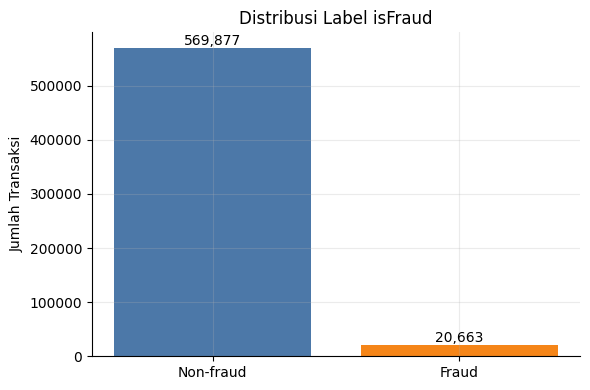

In [38]:
if selected_train_df is not None:
    class_counts = selected_train_df["isFraud"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["Non-fraud", "Fraud"], class_counts.values, color=["#4c78a8", "#f58518"])
    ax.set_title("Distribusi Label isFraud")
    ax.set_ylabel("Jumlah Transaksi")
    for index, value in enumerate(class_counts.values):
        ax.text(index, value, f"{value:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: plot class imbalance dilewati karena raw train data tidak tersedia.")


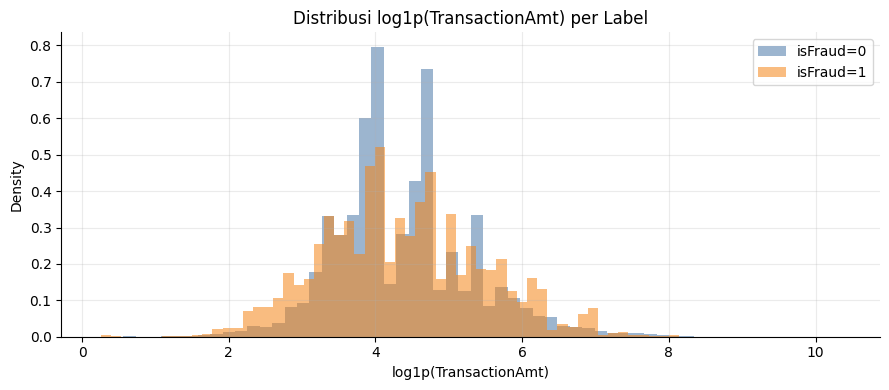

In [39]:
if selected_train_df is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in [(0, "#4c78a8"), (1, "#f58518")]:
        values = np.log1p(selected_train_df.loc[selected_train_df["isFraud"] == label, "TransactionAmt"].dropna())
        ax.hist(values, bins=60, alpha=0.55, density=True, label=f"isFraud={label}", color=color)
    ax.set_title("Distribusi log1p(TransactionAmt) per Label")
    ax.set_xlabel("log1p(TransactionAmt)")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: plot TransactionAmt dilewati karena raw train data tidak tersedia.")


In [40]:
if selected_train_df is not None:
    amount_quantiles = (
        selected_train_df.groupby("isFraud")["TransactionAmt"]
        .quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
        .unstack()
        .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75", 0.9: "p90", 0.95: "p95", 0.99: "p99"})
        .reset_index()
    )
    amount_quantiles = numeric_round_table(amount_quantiles)
else:
    amount_quantiles = note_table("Raw train data tidak tersedia.")

amount_quantiles


,isFraud,q25,median,q75,p90,p95,p99
0,0,43.970000,68.500000,120.000000,267.112000,435.000000,1104.000000
1,1,35.044000,75.000000,161.000000,335.000000,500.000000,994.000000


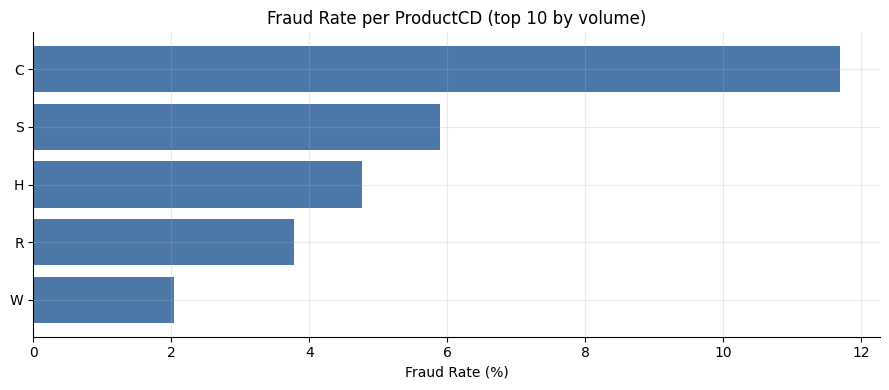

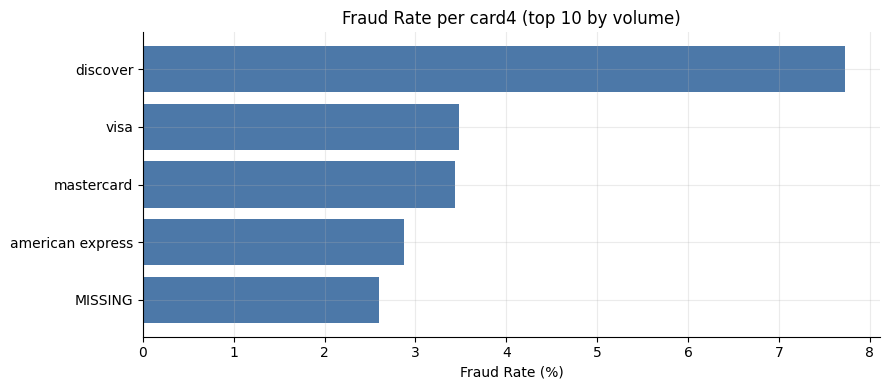

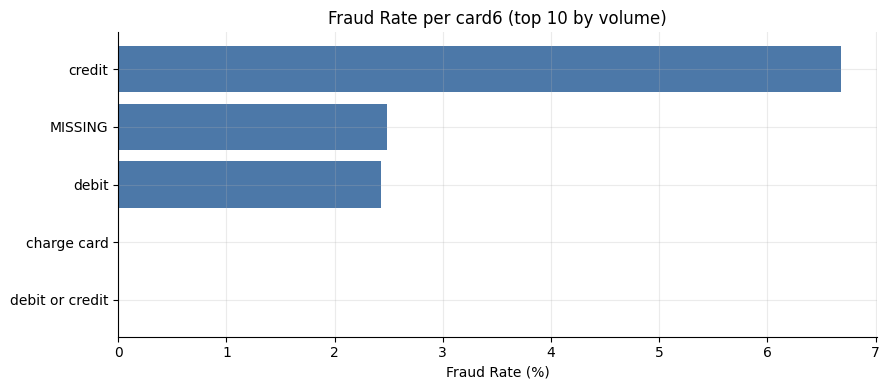

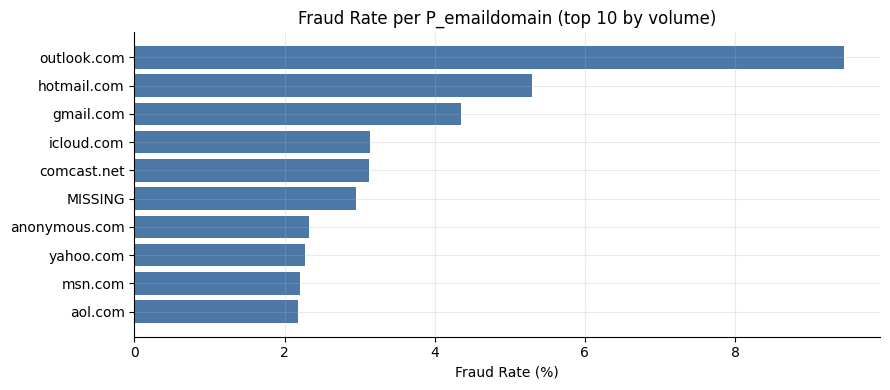

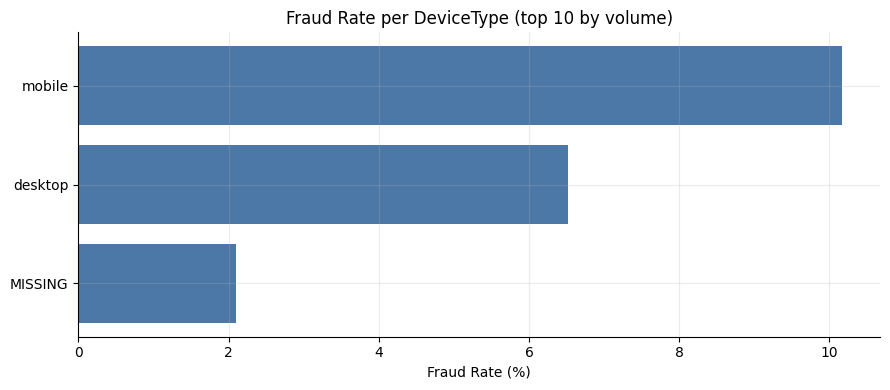

In [41]:
if selected_train_df is not None:
    for column in ["ProductCD", "card4", "card6", "P_emaildomain", "DeviceType"]:
        plot_category_fraud_rate(selected_train_df, column, top_n=10)
else:
    print("Catatan: fraud-rate category plots dilewati karena raw train data tidak tersedia.")


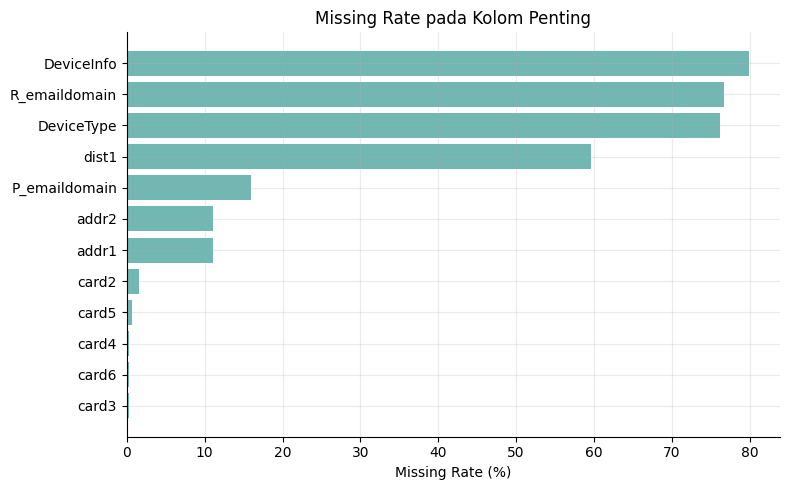

In [42]:
if selected_train_df is not None:
    missing_columns = [
        "card2", "card3", "card4", "card5", "card6", "addr1", "addr2",
        "P_emaildomain", "R_emaildomain", "dist1", "DeviceType", "DeviceInfo",
    ]
    missing_rate = selected_train_df[missing_columns].isna().mean().sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(missing_rate.index, missing_rate.values * 100, color="#72b7b2")
    ax.set_title("Missing Rate pada Kolom Penting")
    ax.set_xlabel("Missing Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: missing-rate plot dilewati karena raw train data tidak tersedia.")


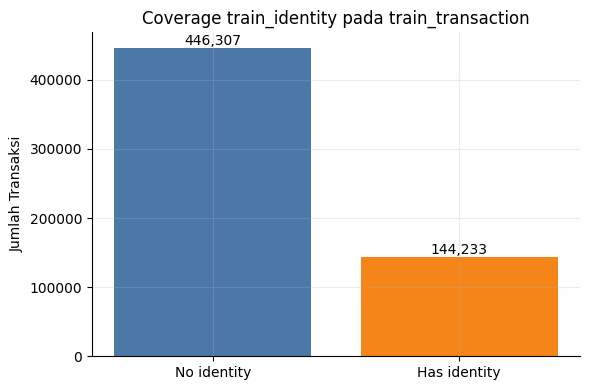

In [43]:
if selected_train_df is not None:
    coverage = selected_train_df["identity_match"].value_counts().rename(index={False: "No identity", True: "Has identity"})
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(coverage.index.astype(str), coverage.values, color=["#4c78a8", "#f58518"])
    ax.set_title("Coverage train_identity pada train_transaction")
    ax.set_ylabel("Jumlah Transaksi")
    for index, value in enumerate(coverage.values):
        ax.text(index, value, f"{value:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: identity coverage plot dilewati karena raw train data tidak tersedia.")


<a id="experiment-flow"></a>
## 5. Experiment Flow

| Tahap | Input | Proses | Output untuk laporan |
| --- | --- | --- | --- |
| Raw data | `train_transaction`, `train_identity` | Merge dengan `TransactionID` | Labeled training dataset |
| Temporal split | Data train berlabel | Urut `TransactionDT`, split 60/20/20 | Train, validation, test kronologis |
| Baseline | Fitur asli IEEE-CIS | LightGBM default dan tuned | Pembanding utama |
| Autoencoder | Fitur `V` dan fitur non-`V` | Latent representation, reconstruction error, AE-LightGBM | Evaluasi kontribusi AE |
| Feature engineering | Entitas, waktu, amount | Count/frequency, statistik amount, fitur waktu | FE-LGBM default dan tuned |
| Ensemble | Skor FE-LGBM dan AE-LGBM | Weighted score ensemble | Model overall terbaik |
| Final report | Artifact eksperimen | Ranking, visualisasi, interpretasi | Bahan bimbingan dan penulisan bab hasil |


<a id="artifact-map"></a>
## 6. Artifact Map

Tabel ini menunjukkan artifact yang menjadi sumber angka dan visualisasi. Tujuannya agar pembimbing dapat menelusuri sumber hasil tanpa membaca seluruh script pada `/src`.


In [44]:
artifact_rows = []
for name, relative_path in ARTIFACTS.items():
    path = resolve_path(relative_path)
    artifact_rows.append(
        {
            "Artifact": name,
            "Path": relative_path,
            "Tersedia": path.exists(),
            "Ukuran (KB)": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
        }
    )

artifact_map = pd.DataFrame(artifact_rows)
artifact_map


,Artifact,Path,Tersedia,Ukuran (KB)
0,train_transaction,data/raw/train_transaction.csv,True,667335.030000
1,train_identity,data/raw/train_identity.csv,True,25907.890000
2,split_summary,outputs/split_summary.json,True,1.460000
3,final_summary,outputs/final_report/final_summary.json,True,2.870000
4,final_model_comparison,outputs/final_report/final_model_comparison.csv,True,3.640000
5,diagnostic_notes,outputs/final_report/diagnostic_notes.md,True,1.700000
6,final_defense_notes,outputs/final_diagnostics/final_defense_notes.md,True,2.540000
7,feature_importance,outputs/optuna/baseline_lgbm_entity_time_amoun...,True,15.270000
8,feature_set_summary,outputs/baseline_lgbm_entity_time_amount_featu...,True,14.280000
9,next_controlled,outputs/final_comparison/next_controlled_exper...,True,3.750000


<a id="temporal-split"></a>
## 7. Temporal Split

Eksperimen menggunakan split kronologis berdasarkan `TransactionDT`. Data diurutkan dari transaksi paling awal ke paling akhir, lalu dibagi menjadi train, validation, dan test dengan rasio 60/20/20.

Split kronologis lebih realistis dibanding random split karena sistem fraud detection di dunia nyata dilatih dari data historis dan digunakan untuk memprediksi transaksi masa depan.


In [45]:
def split_summary_to_frame(summary):
    if not summary:
        return note_table("Ringkasan temporal split tidak tersedia.")
    rows = []
    for key, label in [("train", "Train"), ("validation", "Validation"), ("test", "Test")]:
        stats = summary.get("splits", {}).get(key, {})
        dt_min = stats.get("TransactionDT_min", summary.get(f"{key}_transactiondt_min"))
        dt_max = stats.get("TransactionDT_max", summary.get(f"{key}_transactiondt_max"))
        rows.append({
            "Split": label,
            "Row Count": stats.get("row_count", summary.get(f"{key}_row_count")),
            "Fraud Count": stats.get("fraud_count", summary.get(f"{key}_fraud_count")),
            "Fraud Rate": stats.get("fraud_rate", summary.get(f"{key}_fraud_rate")),
            "TransactionDT Min": dt_min,
            "TransactionDT Max": dt_max,
            "Periode Min (hari)": None if dt_min is None else dt_min / 86400,
            "Periode Max (hari)": None if dt_max is None else dt_max / 86400,
        })
    return numeric_round_table(pd.DataFrame(rows))


split_summary = safe_read_json(ARTIFACTS["split_summary"], "ringkasan temporal split")
split_table = split_summary_to_frame(split_summary)
split_table


,Split,Row Count,Fraud Count,Fraud Rate,TransactionDT Min,TransactionDT Max,Periode Min (hari),Periode Max (hari)
0,Train,354324,11988,0.033833,86400,8745772,1.000000,101.224213
1,Validation,118108,4611,0.039041,8745798,12192842,101.224514,141.120856
2,Test,118108,4064,0.034409,12192900,15811131,141.121528,182.999201


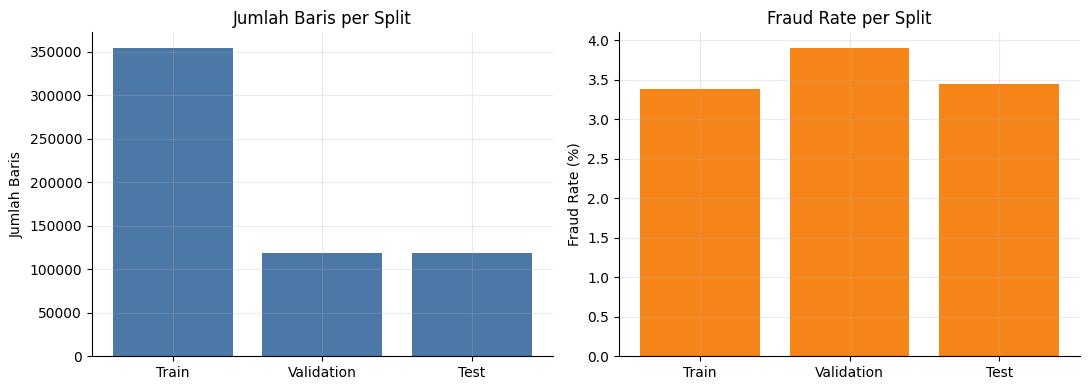

In [46]:
if {"Split", "Row Count", "Fraud Rate"}.issubset(split_table.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(split_table["Split"], split_table["Row Count"], color="#4c78a8")
    axes[0].set_title("Jumlah Baris per Split")
    axes[0].set_ylabel("Jumlah Baris")
    axes[1].bar(split_table["Split"], split_table["Fraud Rate"] * 100, color="#f58518")
    axes[1].set_title("Fraud Rate per Split")
    axes[1].set_ylabel("Fraud Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: plot temporal split dilewati karena ringkasan split tidak tersedia.")


<a id="temporal-eda"></a>
## 8. Temporal EDA

Bagian ini memberi gambaran perubahan volume transaksi dan fraud rate sepanjang waktu. Binning dibuat berdasarkan urutan kronologis agar tiap bin berisi jumlah baris yang relatif seimbang.


In [47]:
def build_temporal_eda(df, bins=20):
    if df is None or df.empty:
        return pd.DataFrame()
    data = df.sort_values("TransactionDT").reset_index(drop=True).copy()
    data["temporal_bin"] = np.floor(np.arange(len(data)) / len(data) * bins).astype(int) + 1
    data["temporal_bin"] = data["temporal_bin"].clip(upper=bins)
    summary = data.groupby("temporal_bin").agg(
        row_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean"),
        transactiondt_min=("TransactionDT", "min"),
        transactiondt_max=("TransactionDT", "max"),
    ).reset_index()
    summary["mid_day"] = ((summary["transactiondt_min"] + summary["transactiondt_max"]) / 2) / 86400
    return summary


temporal_eda = build_temporal_eda(selected_train_df, bins=20)
numeric_round_table(temporal_eda.head()) if not temporal_eda.empty else note_table("Temporal EDA tidak tersedia.")


,temporal_bin,row_count,fraud_count,fraud_rate,transactiondt_min,transactiondt_max,mid_day
0,1,29527,850,0.028787,86400,751937,4.851487
1,2,29527,781,0.026450,751947,1360999,12.227697
2,3,29527,699,0.023673,1361005,1871901,18.708947
3,4,29527,496,0.016798,1871913,2310138,24.201684
4,5,29527,1062,0.035967,2310165,3027036,30.886580


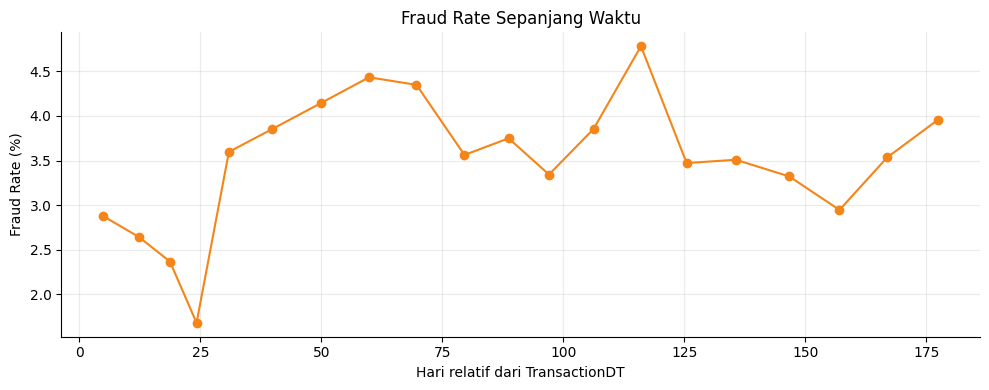

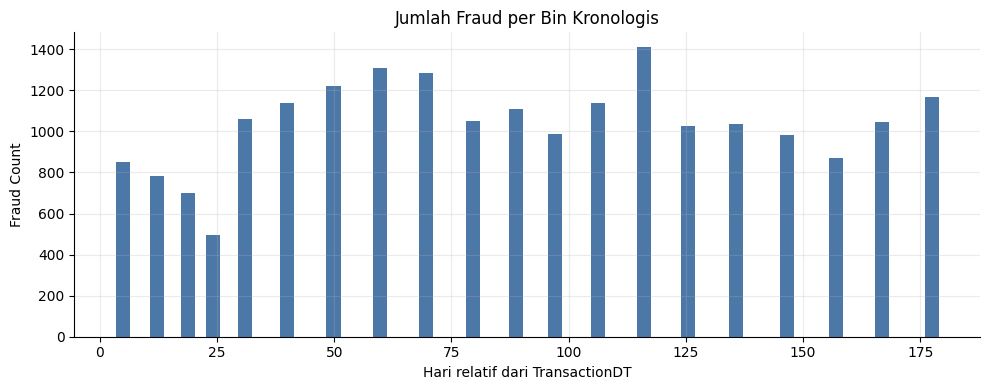

In [48]:
if not temporal_eda.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(temporal_eda["mid_day"], temporal_eda["fraud_rate"] * 100, marker="o", color="#f58518")
    ax.set_title("Fraud Rate Sepanjang Waktu")
    ax.set_xlabel("Hari relatif dari TransactionDT")
    ax.set_ylabel("Fraud Rate (%)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(temporal_eda["mid_day"], temporal_eda["fraud_count"], width=3, color="#4c78a8")
    ax.set_title("Jumlah Fraud per Bin Kronologis")
    ax.set_xlabel("Hari relatif dari TransactionDT")
    ax.set_ylabel("Fraud Count")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: temporal EDA plot dilewati karena raw train data tidak tersedia.")


<a id="experiment-scenarios"></a>
## 9. Experiment Scenarios

| Skenario | Tujuan | Artifact utama | Interpretasi singkat |
| --- | --- | --- | --- |
| Baseline LightGBM | Pembanding awal dengan fitur asli IEEE-CIS. | `outputs/baseline_lgbm`, `outputs/optuna/baseline_lgbm` | Baseline sebelum AE dan feature engineering. |
| AE-LightGBM replacement | Mengganti kelompok fitur `V` dengan representasi laten Autoencoder. | `outputs/ae_lgbm_ld128`, `outputs/optuna/ae_lgbm_ld128` | Menguji apakah kompresi `V` lebih informatif. |
| AE reconstruction error | Menggunakan error rekonstruksi sebagai sinyal anomali. | `outputs/baseline_lgbm_plus_log1p_ae_reconstruction_mse` | Ada sinyal, tetapi bukan model terbaik. |
| Feature-engineered LightGBM | Menambahkan fitur entitas, waktu, dan amount secara leakage-safe. | `outputs/baseline_lgbm_entity_time_amount_features`, `outputs/optuna/baseline_lgbm_entity_time_amount_features` | Peningkatan standalone terbesar. |
| FE + AE score ensemble | Menggabungkan skor FE-LGBM dan AE-LGBM pada level probabilitas. | `outputs/fe_ae_controlled_experiments` | Model overall terbaik. |
| UID / historical experiments | Ablation untuk UID-inspired dan historical velocity features. | `outputs/baseline_lgbm_entity_time_amount_uid_features`, `outputs/baseline_lgbm_entity_time_amount_historical_velocity_features` | Hasil pendukung/negative experiment. |


<a id="final-model-comparison"></a>
## 10. Final Model Comparison

Prioritas artifact:

1. `outputs/final_report/final_model_comparison.csv`
2. `outputs/final_comparison/next_controlled_experiments.csv`
3. `outputs/final_comparison/fe_ae_fine_ensemble_comparison.csv`


In [49]:
def load_final_model_comparison():
    primary = resolve_path(ARTIFACTS["final_model_comparison"])
    if primary.exists():
        print(f"Menggunakan artifact utama: {primary.relative_to(PROJECT_ROOT)}")
        return pd.read_csv(primary)
    register_note("Catatan: final_model_comparison.csv tidak ditemukan; memakai fallback.")
    frames = []
    for key in ["next_controlled", "fe_ae_fine_ensemble"]:
        frame = safe_read_csv(ARTIFACTS[key], context=f"fallback {key}")
        if frame is not None and not frame.empty:
            frames.append(frame)
    if not frames:
        return None
    combined = pd.concat(frames, ignore_index=True, sort=False)
    if {"model_name", "test_pr_auc"}.issubset(combined.columns):
        combined = combined.sort_values("test_pr_auc", ascending=False).drop_duplicates("model_name")
    return combined.reset_index(drop=True)


comparison_df = load_final_model_comparison()
comparison_table = format_metric_table(comparison_df)
comparison_table


Menggunakan artifact utama: outputs\final_report\final_model_comparison.csv


,Rank,Model,Validation PR-AUC,Test PR-AUC,Test ROC-AUC,Precision,Recall,F1,MCC,Threshold,Jumlah Fitur,Standalone
0,1,FE-LGBM tuned + AE-LGBM tuned score ensemble,0.659935,0.533935,0.904215,0.682508,0.420522,0.520402,0.523285,0.340000,NaN,False
1,2,Feature-engineered LightGBM tuned,0.654316,0.529857,0.894602,0.651137,0.436762,0.522828,0.520060,0.310000,519.000000,True
2,3,Feature-engineered LightGBM default,0.627793,0.509117,0.888411,0.706406,0.390748,0.503169,0.513529,0.650000,519.000000,True
3,4,Baseline LightGBM tuned,0.624072,0.501438,0.880276,0.684424,0.373031,0.482879,0.493001,0.530000,432.000000,True
4,5,AE reconstruction error only,0.612429,0.496067,0.872313,0.672096,0.385827,0.490230,0.496619,0.550000,433.000000,True
5,6,AE-LightGBM LD128 tuned,0.610631,0.490686,0.892513,0.601197,0.395423,0.477067,0.473170,0.280000,221.000000,True
6,7,AE-LightGBM LD128 default,0.594149,0.489417,0.879606,0.646141,0.376969,0.476146,0.480349,0.610000,221.000000,True
7,8,Normal-only AE reconstruction error,0.609163,0.487441,0.873980,0.662138,0.371801,0.476205,0.483385,0.580000,433.000000,True
8,9,Baseline LightGBM default,0.602433,0.485756,0.875195,0.672622,0.370571,0.477868,0.486715,0.700000,432.000000,True


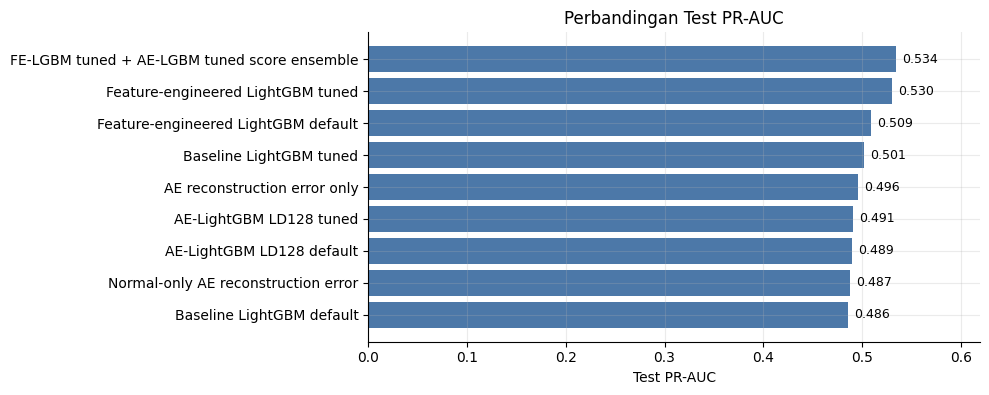

In [50]:
plot_bar(
    comparison_df,
    metric_col="test_pr_auc",
    title="Perbandingan Test PR-AUC",
    xlabel="Test PR-AUC",
    top_n=12,
    color="#4c78a8",
)


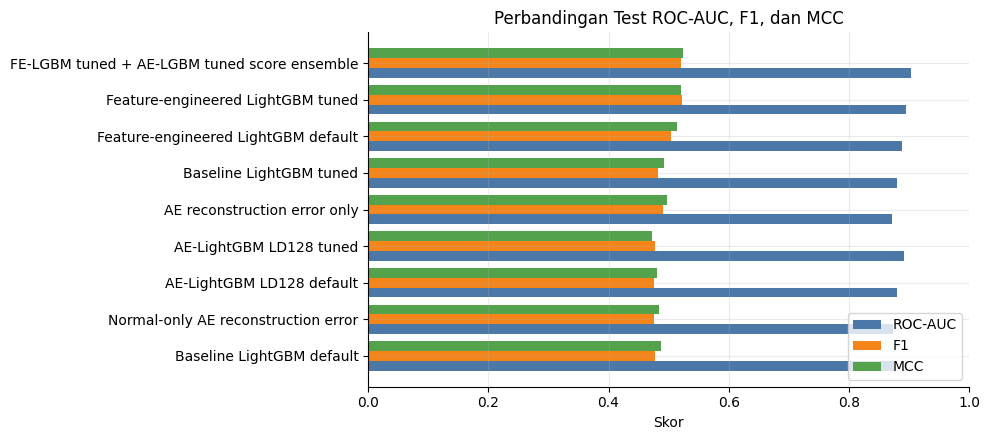

In [51]:
plot_grouped_metric_bars(
    comparison_df,
    metric_cols=["test_roc_auc", "test_f1", "test_mcc"],
    top_n=9,
    title="Perbandingan Test ROC-AUC, F1, dan MCC",
)


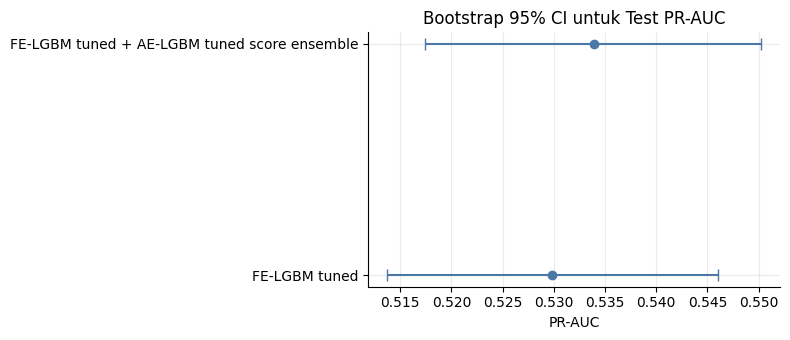

In [52]:
bootstrap_ci = safe_read_csv(ARTIFACTS["bootstrap_ci"], "bootstrap PR-AUC CI")
if bootstrap_ci is not None and not bootstrap_ci.empty:
    plot_df = bootstrap_ci.copy()
    y = np.arange(len(plot_df))
    lower = plot_df["point_estimate_pr_auc"] - plot_df["ci_lower_95"]
    upper = plot_df["ci_upper_95"] - plot_df["point_estimate_pr_auc"]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.errorbar(plot_df["point_estimate_pr_auc"], y, xerr=[lower, upper], fmt="o", color="#4c78a8", capsize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["model"])
    ax.set_title("Bootstrap 95% CI untuk Test PR-AUC")
    ax.set_xlabel("PR-AUC")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: bootstrap CI plot dilewati karena artifact tidak tersedia.")


<a id="business-impact"></a>
## 11. Operational Threshold & Business-Impact Simulation

Bagian ini menggunakan simulasi threshold pada target false positive rate (FPR). **Disclaimer:** `TransactionAmt` adalah nominal transaksi, bukan estimasi kerugian finansial aktual; analisis ini adalah simulasi operasional, bukan estimasi monetary saving.


In [53]:
operational_fpr = safe_read_csv(ARTIFACTS["operational_fpr"], "operational FPR simulation")
operational_delta = safe_read_csv(ARTIFACTS["operational_delta"], "operational FPR delta")

if operational_fpr is not None and not operational_fpr.empty:
    ops_cols = ["model", "fpr_target", "selected_threshold", "actual_fpr", "precision", "tpr_recall", "true_positive_count", "false_positive_count"]
    ops_table = numeric_round_table(operational_fpr[ops_cols].copy())
else:
    ops_table = note_table("Operational FPR simulation tidak tersedia.")

ops_table


,model,fpr_target,selected_threshold,actual_fpr,precision,tpr_recall,true_positive_count,false_positive_count
0,FE-LGBM tuned,0.005000,0.470217,0.004989,0.737546,0.393455,1599,569
1,FE+AE score ensemble,0.005000,0.438548,0.004998,0.735253,0.389518,1583,570
2,FE-LGBM tuned,0.010000,0.260305,0.009987,0.615463,0.448573,1823,1139
3,FE+AE score ensemble,0.010000,0.251258,0.009944,0.619208,0.453740,1844,1134
4,FE-LGBM tuned,0.020000,0.115403,0.019975,0.481802,0.521161,2118,2278
5,FE+AE score ensemble,0.020000,0.123148,0.019975,0.484732,0.527313,2143,2278
6,FE-LGBM tuned,0.050000,0.032272,0.049963,0.313163,0.639272,2598,5698
7,FE+AE score ensemble,0.050000,0.042527,0.049981,0.317774,0.653297,2655,5700


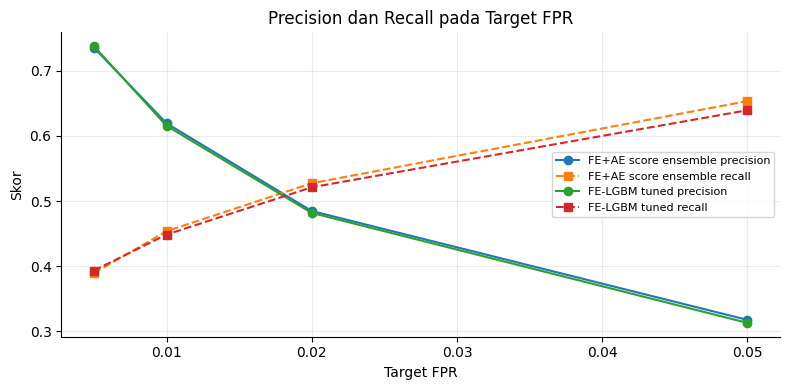

In [54]:
if operational_fpr is not None and not operational_fpr.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for model, group in operational_fpr.groupby("model"):
        ax.plot(group["fpr_target"], group["precision"], marker="o", label=f"{model} precision")
        ax.plot(group["fpr_target"], group["tpr_recall"], marker="s", linestyle="--", label=f"{model} recall")
    ax.set_title("Precision dan Recall pada Target FPR")
    ax.set_xlabel("Target FPR")
    ax.set_ylabel("Skor")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: precision/recall operational plot dilewati.")


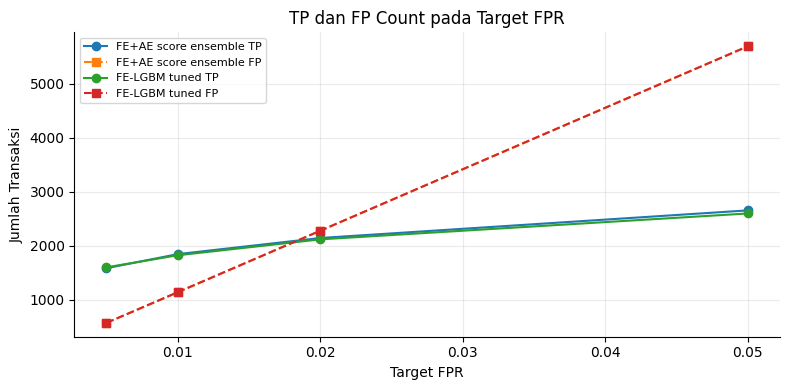

In [55]:
if operational_fpr is not None and not operational_fpr.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for model, group in operational_fpr.groupby("model"):
        ax.plot(group["fpr_target"], group["true_positive_count"], marker="o", label=f"{model} TP")
        ax.plot(group["fpr_target"], group["false_positive_count"], marker="s", linestyle="--", label=f"{model} FP")
    ax.set_title("TP dan FP Count pada Target FPR")
    ax.set_xlabel("Target FPR")
    ax.set_ylabel("Jumlah Transaksi")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: TP/FP operational plot dilewati.")


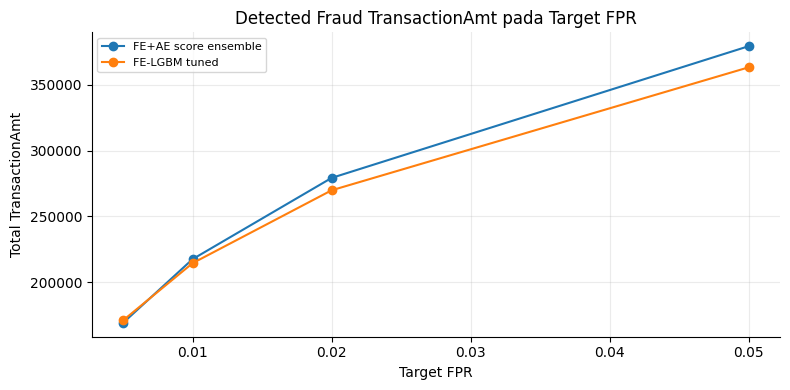

In [56]:
if operational_fpr is not None and not operational_fpr.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for model, group in operational_fpr.groupby("model"):
        ax.plot(group["fpr_target"], group["detected_fraud_transaction_amt_sum"], marker="o", label=model)
    ax.set_title("Detected Fraud TransactionAmt pada Target FPR")
    ax.set_xlabel("Target FPR")
    ax.set_ylabel("Total TransactionAmt")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: detected amount plot dilewati.")


In [57]:
if operational_delta is not None and not operational_delta.empty:
    delta_cols = [
        "ensemble_minus_fe_true_positive_count",
        "ensemble_minus_fe_false_positive_count",
        "ensemble_minus_fe_precision",
        "ensemble_minus_fe_recall",
    ]
    delta_table = numeric_round_table(operational_delta[["fpr_target"] + delta_cols].copy())
else:
    delta_table = note_table("Operational delta summary tidak tersedia.")

delta_table


,fpr_target,ensemble_minus_fe_true_positive_count,ensemble_minus_fe_false_positive_count,ensemble_minus_fe_precision,ensemble_minus_fe_recall
0,0.005000,-16,1,-0.002293,-0.003937
1,0.010000,21,-5,0.003745,0.005167
2,0.020000,25,0,0.002930,0.006152
3,0.050000,57,2,0.004611,0.014026


<a id="autoencoder-findings"></a>
## 12. Autoencoder Findings

Autoencoder tidak mendominasi sebagai model standalone. AE-LightGBM dengan latent representation dan pendekatan reconstruction error sama-sama memiliki sinyal fraud, tetapi performanya masih berada di bawah tuned baseline dan Feature-engineered LightGBM.

Kesimpulan untuk bimbingan:

- AE standalone tidak mengungguli tuned LightGBM/FE model pada chronological test split.
- Reconstruction error mengandung sinyal anomali, tetapi belum cukup kuat sebagai model utama.
- AE lebih tepat diposisikan sebagai sinyal komplementer pada score-level ensemble.


In [58]:
prepared_comparison = prepare_comparison(comparison_df)
if not prepared_comparison.empty:
    ae_mask = prepared_comparison["model_name"].astype(str).str.contains(
        "AE|Autoencoder|reconstruction|ae_", case=False, regex=True
    )
    ae_table = format_metric_table(prepared_comparison.loc[ae_mask])
else:
    ae_table = note_table("Data perbandingan AE tidak tersedia.")

ae_table


,Rank,Model,Validation PR-AUC,Test PR-AUC,Test ROC-AUC,Precision,Recall,F1,MCC,Threshold,Jumlah Fitur,Standalone
0,1,FE-LGBM tuned + AE-LGBM tuned score ensemble,0.659935,0.533935,0.904215,0.682508,0.420522,0.520402,0.523285,0.340000,NaN,False
4,5,AE reconstruction error only,0.612429,0.496067,0.872313,0.672096,0.385827,0.490230,0.496619,0.550000,433.000000,True
5,6,AE-LightGBM LD128 tuned,0.610631,0.490686,0.892513,0.601197,0.395423,0.477067,0.473170,0.280000,221.000000,True
6,7,AE-LightGBM LD128 default,0.594149,0.489417,0.879606,0.646141,0.376969,0.476146,0.480349,0.610000,221.000000,True
7,8,Normal-only AE reconstruction error,0.609163,0.487441,0.873980,0.662138,0.371801,0.476205,0.483385,0.580000,433.000000,True


In [59]:
score_correlation = safe_read_json(ARTIFACTS["score_correlation"], "score correlation summary")
if score_correlation:
    score_corr_table = pd.DataFrame(
        [{"Metric": key, "Value": value} for key, value in score_correlation.items() if not isinstance(value, (dict, list))]
    )
else:
    score_corr_table = note_table("Score correlation summary tidak tersedia.")

score_corr_table


,Metric,Value
0,fraud_count,4064
1,fraud_rate,0.034409
2,pearson_correlation,0.901977
3,rows,118108
4,spearman_correlation,0.746330
5,split,test


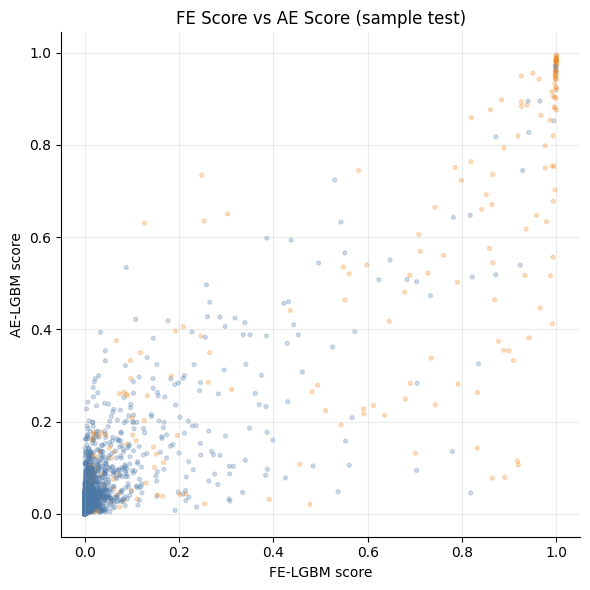

In [60]:
scores_test = safe_read_csv(ARTIFACTS["scores_test"], "FE/AE ensemble test scores")
if scores_test is not None and not scores_test.empty:
    sample_scores = scores_test.sample(n=min(8000, len(scores_test)), random_state=42)
    colors = np.where(sample_scores["isFraud"] == 1, "#f58518", "#4c78a8")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(sample_scores["fe_lgbm_tuned_score"], sample_scores["ae_lgbm_ld128_tuned_score"], s=8, alpha=0.25, c=colors)
    ax.set_title("FE Score vs AE Score (sample test)")
    ax.set_xlabel("FE-LGBM score")
    ax.set_ylabel("AE-LGBM score")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: score scatter dilewati karena artifact tidak tersedia.")


<a id="diagnostic-notes"></a>
## 13. Diagnostic Notes

Bagian ini membaca diagnostic artifacts final. Fokusnya bukan raw log, tetapi ringkasan diagnostik yang membantu pembimbing menilai kekuatan klaim.


In [61]:
diagnostic_text = safe_read_text(ARTIFACTS["diagnostic_notes"], "diagnostic notes")
final_defense_text = safe_read_text(ARTIFACTS["final_defense_notes"], "final defense notes")
diagnostic_table = markdown_bullets_to_frame(diagnostic_text)
final_defense_table = markdown_bullets_to_frame(final_defense_text)
diagnostic_table


,Area,Temuan
0,Scope,These diagnostics use existing artifacts only;...
1,Scope,Data labels come from the chronological valida...
2,Scope,Kaggle competition test files are not used.
3,Reconstruction Error,Validation reconstruction-error anomaly metric...
4,Reconstruction Error,Test reconstruction-error anomaly metrics: PR-...
5,Reconstruction Error,"On the test split, median reconstruction MSE i..."
6,Reconstruction Error,Interpretation: reconstruction error alone sho...
7,Bootstrap PR-AUC,"Point delta, ensemble minus FE-LGBM tuned: 0.0..."
8,Bootstrap PR-AUC,"Paired bootstrap 95% CI for delta: [0.002033, ..."
9,Bootstrap PR-AUC,The paired bootstrap 95% CI for the PR-AUC del...


In [62]:
final_defense_table


,Area,Temuan
0,Scope,Existing artifacts only; no model training is ...
1,Scope,Chronological validation/test splits are recre...
2,Scope,Kaggle competition test files are not used.
3,Temporal Degradation,The ensemble PR-AUC exceeds FE-LGBM in 5/5 chr...
4,Temporal Degradation,Best ensemble bin: bin 2 with PR-AUC 0.585766;...
5,Temporal Degradation,The last chronological bin does not collapse r...
6,FE vs AE Score Complementarity,FE and AE scores are moderately to strongly co...
7,Reconstruction Error,Validation reconstruction-error-as-score PR-AU...
8,Reconstruction Error,Test reconstruction-error-as-score PR-AUC=0.09...
9,Reconstruction Error,Interpretation: robust AE LD128 reconstruction...


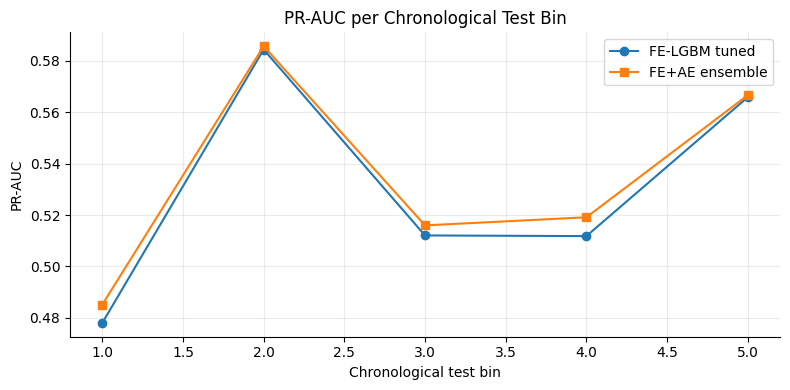

In [63]:
temporal_degradation = safe_read_csv(ARTIFACTS["temporal_degradation"], "temporal degradation by bin")
if temporal_degradation is not None and not temporal_degradation.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(temporal_degradation["bin"], temporal_degradation["fe_lgbm_tuned_pr_auc"], marker="o", label="FE-LGBM tuned")
    ax.plot(temporal_degradation["bin"], temporal_degradation["fe_ae_ensemble_pr_auc"], marker="s", label="FE+AE ensemble")
    ax.set_title("PR-AUC per Chronological Test Bin")
    ax.set_xlabel("Chronological test bin")
    ax.set_ylabel("PR-AUC")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: temporal degradation plot dilewati.")


In [64]:
recon_summary = safe_read_csv(ARTIFACTS["reconstruction_summary"], "reconstruction error class summary")
if recon_summary is not None and not recon_summary.empty:
    recon_table = numeric_round_table(recon_summary[["split", "class_label", "count", "median", "p90", "p95", "p99"]])
else:
    recon_table = note_table("Reconstruction error class summary tidak tersedia.")

recon_table


,split,class_label,count,median,p90,p95,p99
0,validation,non_fraud,113497,0.000760,0.012721,0.023361,0.102976
1,validation,fraud,4611,0.010715,0.108723,0.170145,0.413353
2,test,non_fraud,114044,0.000787,0.015594,0.036004,3.976008
3,test,fraud,4064,0.009531,0.107011,0.183920,0.432284


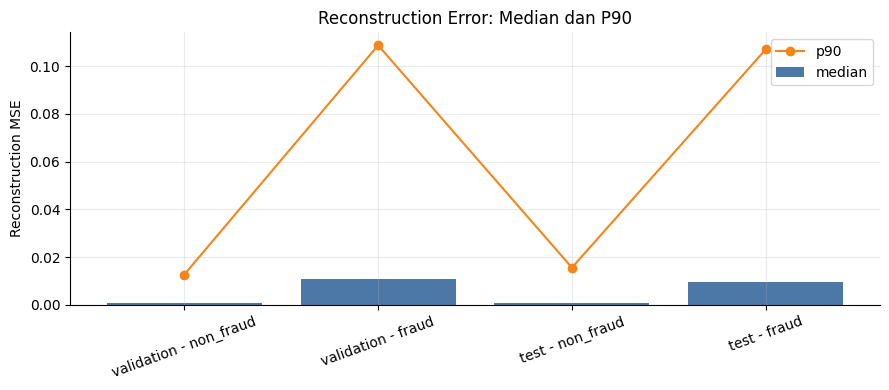

In [65]:
if recon_summary is not None and not recon_summary.empty:
    plot_df = recon_summary.copy()
    plot_df["label"] = plot_df["split"] + " - " + plot_df["class_label"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(plot_df["label"], plot_df["median"], color="#4c78a8", label="median")
    ax.plot(plot_df["label"], plot_df["p90"], marker="o", color="#f58518", label="p90")
    ax.set_title("Reconstruction Error: Median dan P90")
    ax.set_ylabel("Reconstruction MSE")
    ax.legend()
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: reconstruction error plot dilewati.")


In [66]:
inference_complexity = safe_read_csv(ARTIFACTS["inference_complexity"], "inference complexity summary")
if inference_complexity is not None and not inference_complexity.empty:
    inference_table = numeric_round_table(
        inference_complexity[["model", "feature_columns", "ms_per_10000_rows", "relative_time_vs_fe", "relative_overhead_vs_fe_pct"]]
    )
else:
    inference_table = note_table("Inference complexity summary tidak tersedia.")

inference_table


,model,feature_columns,ms_per_10000_rows,relative_time_vs_fe,relative_overhead_vs_fe_pct
0,FE-LGBM tuned,519,3326.455256,1.000000,0.000000
1,AE-LGBM tuned,221,1221.094769,0.367086,-63.291412
2,FE-LGBM tuned + AE-LGBM tuned score ensemble,740,4869.485669,1.463866,46.386628


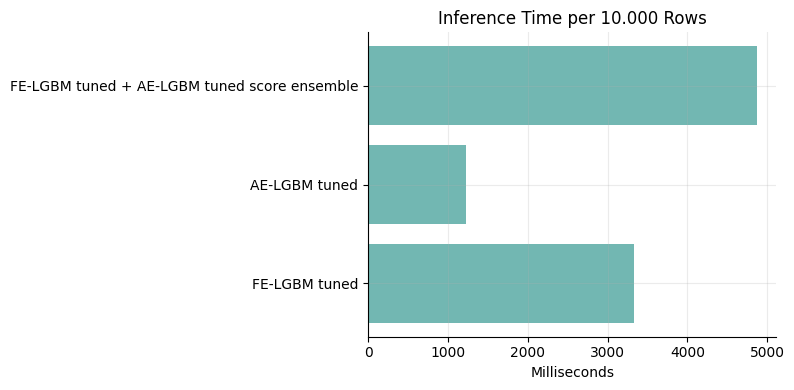

In [67]:
if inference_complexity is not None and not inference_complexity.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(inference_complexity["model"], inference_complexity["ms_per_10000_rows"], color="#72b7b2")
    ax.set_title("Inference Time per 10.000 Rows")
    ax.set_xlabel("Milliseconds")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: inference complexity plot dilewati.")


Interpretasi diagnostik utama:

- Reconstruction error memisahkan fraud dan non-fraud secara statistik, tetapi performa anomaly-only jauh di bawah supervised LightGBM.
- Bootstrap delta ensemble terhadap FE-LGBM tuned mendukung bahwa peningkatan PR-AUC kecil tetapi stabil pada diagnostic run ini.
- Kompleksitas inference ensemble lebih tinggi karena membutuhkan dua pipeline model, sehingga trade-off deployment perlu dibahas.


<a id="feature-engineering-findings"></a>
## 14. Feature Engineering Findings

Feature engineering difokuskan pada tiga kelompok:

- **Entity features:** count/frequency berdasarkan kombinasi `card1`, `addr1`, `P_emaildomain`, `DeviceInfo`, dan entitas lain.
- **Time features:** turunan `TransactionDT`, seperti hari, jam, minggu relatif, dan encoding siklik jam transaksi.
- **Amount features:** transformasi `TransactionAmt`, statistik nominal per entitas, serta deviasi transaksi terhadap pola historis train.

Semua mapping feature engineering dipelajari dari train split agar validation dan test tidak bocor ke proses pembuatan fitur.


In [68]:
feature_set_summary = safe_read_json(ARTIFACTS["feature_set_summary"], "feature set summary")
if feature_set_summary:
    features = feature_set_summary.get("engineered_features", [])
    family_rows = [
        {"Family": "Amount transform", "Count": sum(f.startswith("TransactionAmt") for f in features)},
        {"Family": "Time", "Count": sum(f.startswith(("transaction_", "sin_", "cos_")) for f in features)},
        {"Family": "Count/Frequency", "Count": sum(f.startswith(("count_", "freq_")) for f in features)},
        {"Family": "Amount statistics", "Count": sum(f.startswith("amt_") for f in features)},
    ]
    feature_family_table = pd.DataFrame(family_rows)
else:
    feature_family_table = note_table("Feature set summary tidak tersedia.")

feature_family_table


,Family,Count
0,Amount transform,5
1,Time,6
2,Count/Frequency,34
3,Amount statistics,42


In [69]:
def build_feature_importance_table(feature_importance_df):
    if feature_importance_df is None or feature_importance_df.empty:
        return pd.DataFrame(), note_table("Feature importance tidak tersedia.")
    fi = feature_importance_df.copy()
    fi["importance_gain"] = pd.to_numeric(fi["importance_gain"], errors="coerce")
    fi["importance_split"] = pd.to_numeric(fi.get("importance_split"), errors="coerce")
    top30 = fi.dropna(subset=["importance_gain"]).sort_values("importance_gain", ascending=False).head(30).reset_index(drop=True)
    top30.insert(0, "rank", np.arange(1, len(top30) + 1))
    engineered_prefixes = ("amt_", "count_", "freq_", "transaction_", "sin_", "cos_", "TransactionAmt_")
    top30["kelompok"] = np.where(
        top30["feature"].isin(HIGHLIGHT_FEATURES), "engineered-highlight",
        np.where(top30["feature"].astype(str).str.startswith(engineered_prefixes), "engineered", "original"),
    )
    table = top30[["rank", "feature", "kelompok", "importance_split", "importance_gain"]].copy()
    return top30, numeric_round_table(table)


feature_importance_df = safe_read_csv(ARTIFACTS["feature_importance"], "feature importance FE-LGBM tuned")
top30_features, feature_table = build_feature_importance_table(feature_importance_df)
feature_table


,rank,feature,kelompok,importance_split,importance_gain
0,1,V258,original,243,568462.901781
1,2,V70,original,181,349238.722093
2,3,C14,original,1940,322701.682893
3,4,V294,original,383,321076.545440
4,5,D2,original,4779,302227.221213
5,6,TransactionDT,original,14081,271857.868035
6,7,DeviceInfo,original,5147,244936.219508
7,8,C13,original,4157,241212.058091
8,9,P_emaildomain,original,5102,238448.899696
9,10,id_31,original,4928,226641.704232


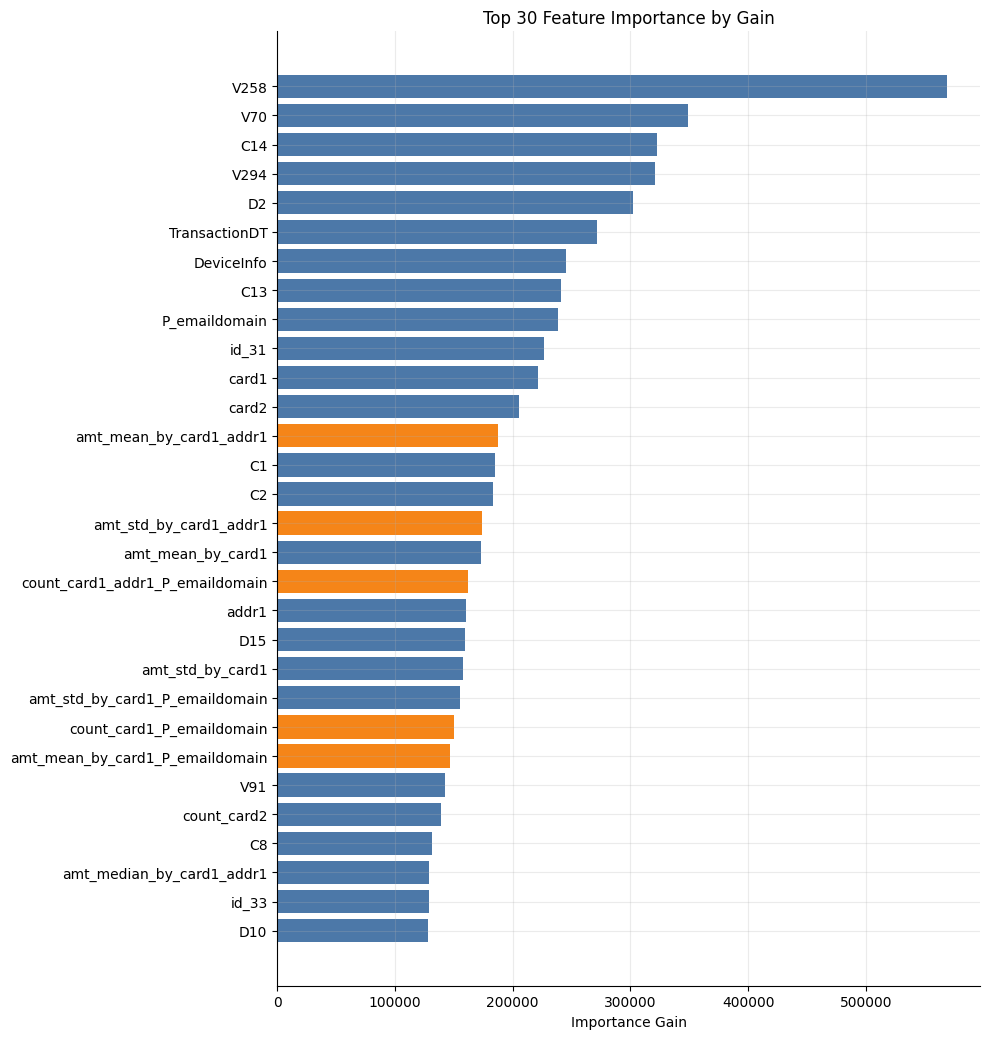

In [70]:
if top30_features is not None and not top30_features.empty:
    plot_features = top30_features.sort_values("importance_gain", ascending=True)
    colors = np.where(plot_features["feature"].isin(HIGHLIGHT_FEATURES), "#f58518", "#4c78a8")
    fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(plot_features))))
    ax.barh(plot_features["feature"], plot_features["importance_gain"], color=colors)
    ax.set_title("Top 30 Feature Importance by Gain")
    ax.set_xlabel("Importance Gain")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: plot feature importance dilewati karena artifact tidak tersedia.")


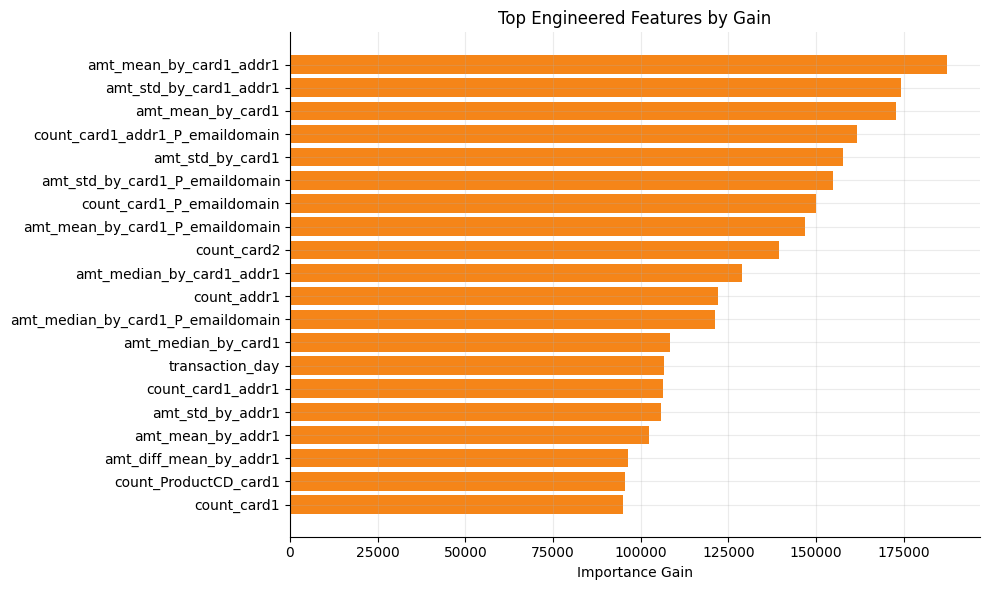

In [71]:
if feature_importance_df is not None and not feature_importance_df.empty:
    engineered_mask = feature_importance_df["feature"].astype(str).str.startswith(
        ("amt_", "count_", "freq_", "transaction_", "sin_", "cos_", "TransactionAmt_")
    )
    engineered_top = feature_importance_df.loc[engineered_mask].copy()
    engineered_top["importance_gain"] = pd.to_numeric(engineered_top["importance_gain"], errors="coerce")
    engineered_top = engineered_top.sort_values("importance_gain", ascending=False).head(20).sort_values("importance_gain")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(engineered_top["feature"], engineered_top["importance_gain"], color="#f58518")
    ax.set_title("Top Engineered Features by Gain")
    ax.set_xlabel("Importance Gain")
    plt.tight_layout()
    plt.show()
else:
    print("Catatan: engineered feature importance plot dilewati.")


Fitur engineered yang penting antara lain `amt_mean_by_card1_addr1`, `amt_std_by_card1_addr1`, `count_card1_addr1_P_emaildomain`, `count_card1_P_emaildomain`, dan `amt_mean_by_card1_P_emaildomain`. Pola ini mendukung klaim bahwa konteks entitas dan nominal transaksi relevan untuk fraud detection.


<a id="ablation-negative"></a>
## 15. Ablation & Negative Experiments

Bagian ini merangkum eksperimen tambahan yang membantu membatasi klaim. Hasil yang tidak menjadi model utama tetap penting karena menunjukkan pendekatan mana yang belum memberikan peningkatan konsisten.


In [72]:
def compact_comparison(path_key, label, max_rows=8):
    df = safe_read_csv(ARTIFACTS[path_key], context=label)
    if df is None or df.empty:
        return note_table(f"{label} tidak tersedia.")
    data = prepare_comparison(df)
    columns = [c for c in ["model_name", "score_type", "validation_pr_auc", "test_pr_auc", "test_roc_auc", "test_f1", "test_mcc"] if c in data.columns]
    if "test_pr_auc" in data.columns:
        data = data.sort_values("test_pr_auc", ascending=False)
    return numeric_round_table(data[columns].head(max_rows).copy())


ablation_tables = {
    "UID/Historical/Recon": compact_comparison("next_controlled", "next controlled experiments"),
    "Latent Dim": compact_comparison("latent_ablation", "latent dimension ablation"),
    "AE Augmented": compact_comparison("ae_augmented", "AE augmented comparison"),
    "Three Model Ensemble": compact_comparison("three_model_ensemble", "three model ensemble comparison"),
}
ablation_tables["UID/Historical/Recon"]


,model_name,validation_pr_auc,test_pr_auc,test_roc_auc,test_f1,test_mcc
0,baseline_lgbm_entity_time_amount_features_tuned,0.654316,0.529857,0.894602,0.522828,0.520060
1,baseline_lgbm_entity_time_amount_features_default,0.627793,0.509117,0.888411,0.503169,0.513529
2,score_ensemble_baseline_tuned_ae_lgbm_ld128_tuned,0.633749,0.508124,0.894592,0.492155,0.497342
3,baseline_lgbm_entity_time_amount_uid_features_...,0.625481,0.507254,0.887956,0.501393,0.506370
4,baseline_lgbm_entity_time_amount_historical_ve...,0.628193,0.502726,0.882573,0.495463,0.506450
5,baseline_lgbm_tuned,0.624072,0.501438,0.880276,0.482879,0.493001
6,baseline_lgbm_plus_log1p_ae_reconstruction_mse...,0.612429,0.496067,0.872313,0.490230,0.496619
7,baseline_lgbm_plus_ae_reconstruction_mse_default,0.612429,0.496067,0.872313,0.490230,0.496619


In [73]:
ablation_tables["Latent Dim"]


,model_name,test_pr_auc,test_roc_auc,test_f1,test_mcc
0,ae_lgbm_ld128,0.489417,0.879606,0.476146,0.480349
1,baseline_lgbm,0.485756,0.875195,0.477868,0.486715
2,ae_lgbm_ld32,0.481593,0.881512,0.470426,0.472018
3,ae_lgbm_ld64,0.481166,0.882263,0.459888,0.477504


In [74]:
ablation_tables["AE Augmented"]


,model_name,test_pr_auc,test_roc_auc,test_f1,test_mcc
0,baseline_lgbm_tuned,0.501438,0.880276,0.482879,0.493001
1,ae_lgbm_ld128_tuned,0.490686,0.892513,0.477067,0.473170
2,ae_lgbm_ld128_default,0.489417,0.879606,0.476146,0.480349
3,baseline_lgbm_default,0.485756,0.875195,0.477868,0.486715
4,ae_augmented_lgbm_ld128_default,0.485417,0.876654,0.472795,0.478038


In [75]:
ablation_tables["Three Model Ensemble"]


,model_name,validation_pr_auc,test_pr_auc,test_roc_auc,test_f1,test_mcc
0,three_model_score_ensemble,0.659664,0.533952,0.903265,0.520037,0.523795
1,current_best_fe_ae_tuned_score_ensemble,0.659935,0.533935,0.904215,0.520402,0.523285


Interpretasi ablation:

- UID-inspired dan historical velocity features dicatat sebagai eksperimen pendukung, bukan klaim utama.
- Variasi latent/AE augmentation membantu menunjukkan bahwa AE belum konsisten mengalahkan feature-engineered supervised model.
- Ensemble yang lebih kompleks perlu dibandingkan dengan biaya maintenance dan stabilitas validasi temporal.


<a id="final-model"></a>
## 16. Final Model

Model overall terbaik:

| Model | Test PR-AUC | Test ROC-AUC | F1 | MCC |
| --- | ---: | ---: | ---: | ---: |
| FE-LGBM tuned + AE-LGBM tuned score ensemble | 0.533935 | 0.904215 | 0.520402 | 0.523285 |

Model standalone terbaik:

| Model | Test PR-AUC |
| --- | ---: |
| Feature-engineered LightGBM tuned | 0.529857 |

Kesimpulan model: feature engineering memberi peningkatan utama, sedangkan Autoencoder memberi tambahan sinyal kecil sebagai bagian dari ensemble skor.


<a id="discussion"></a>
## 17. Discussion

Autoencoder tidak menjadi model standalone terbaik karena fitur `V` pada IEEE-CIS sudah merupakan fitur hasil rekayasa/transformasi. Representasi laten tidak selalu membawa informasi yang lebih kuat dibanding fitur asli dan fitur tabular yang dipelajari LightGBM.

Feature engineering berbasis entitas, waktu, dan amount meningkatkan performa karena fraud sering terlihat sebagai perubahan pola pada kombinasi kartu, alamat, email domain, perangkat, waktu transaksi, dan nominal pembayaran.

Score-level ensemble membantu karena FE-LGBM dan AE-LGBM tidak sepenuhnya mempelajari sinyal yang sama. Namun, peningkatan ensemble relatif kecil sehingga klaimnya perlu ditulis proporsional.

Performa validation yang lebih tinggi daripada test dapat dijelaskan oleh temporal drift dan fakta bahwa validation dipakai untuk tuning, threshold selection, dan model selection. Test split berada pada periode lebih akhir, sehingga lebih merepresentasikan generalisasi ke masa depan.

Hasil ini dapat lebih rendah daripada leaderboard Kaggle atau paper dengan random split, UID reconstruction penuh, atau ensemble besar. Perbandingan tersebut perlu dijelaskan karena setup evaluasi penelitian ini lebih ketat secara temporal.


<a id="limitations-future-work"></a>
## 18. Limitations & Future Work

Keterbatasan utama:

- Validasi temporal masih menggunakan satu validation window dan satu test window.
- UID reconstruction belum selengkap solusi Kaggle tingkat atas.
- Jumlah trial Optuna dibatasi oleh komputasi.
- Ensemble masih terbatas pada kombinasi skor model utama.

Arah pengembangan:

- Rolling temporal validation untuk mengukur stabilitas lintas periode.
- UID reconstruction yang lebih robust dan leakage-aware.
- Cost-sensitive thresholding sesuai biaya false positive dan false negative.
- Kalibrasi probabilitas agar skor lebih mudah diinterpretasikan.
- Multi-model ensemble dengan variasi seed/model family yang tetap menjaga validasi temporal.


<a id="advisor-checklist"></a>
## 19. Checklist Diskusi Bimbingan

Poin yang dapat dibawa ke konsultasi pembimbing:

- Apakah chronological split 60/20/20 sudah cukup kuat untuk klaim evaluasi, atau perlu rolling validation?
- Apakah kontribusi Autoencoder sebaiknya ditulis sebagai kontribusi utama atau sebagai sinyal komplementer?
- Apakah feature engineering berbasis entitas/waktu/amount sudah cukup dijelaskan sebagai kontribusi metode?
- Apakah hasil UID/historical velocity perlu masuk bab utama atau cukup sebagai ablation/future work?
- Apakah threshold F1/MCC sudah sesuai tujuan penelitian, atau perlu diskusi cost-sensitive thresholding?
- Apakah perbandingan dengan Kaggle leaderboard perlu diberi disclaimer eksplisit terkait random split/leaderboard/ensemble?


<a id="execution-notes"></a>
## 20. Catatan Eksekusi Notebook

Cell terakhir merangkum artifact yang hilang saat notebook dijalankan. Jika artifact tidak tersedia, bagian terkait dilewati tanpa menghentikan notebook.


In [76]:
if MISSING_NOTES:
    execution_notes = pd.DataFrame({"Catatan artifact": MISSING_NOTES})
else:
    execution_notes = pd.DataFrame({"Catatan artifact": ["Semua artifact utama yang digunakan tersedia."]})

execution_notes


,Catatan artifact
0,Semua artifact utama yang digunakan tersedia.
